# EDA: everything "waterfront" in the CB1 record

Scope: every meeting whose full text (minutes + attachments + OCR'd scans)
contains the word "waterfront" — then what got voted on in those meetings,
why, and who was speaking.

One structural fact shapes everything below: CB1 has a standing
**Parks & Waterfront Committee**, so the bare word matches 92 of 108
meetings via boilerplate. Mention *intensity* is what separates ritual
(committee report happened) from an actual waterfront fight.

In [1]:
import json
import re
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_colwidth", 160)
con = duckdb.connect()
for t in ("meetings", "licenses", "votes", "speakers"):
    con.execute(f"CREATE VIEW {t} AS SELECT * FROM '../data/db/{t}.parquet'")

def q(sql):
    return con.execute(sql).df()

# full-text index (text layer + vision OCR)
_meet = json.loads(Path("../data/meetings.json").read_text())["meetings"]
_sha2mid = {f["sha256"]: mid for mid, m in _meet.items() for f in m["files"]}
_texts = {}
for _tf in Path("../data/interim/text").glob("*.json"):
    _mid = _sha2mid.get(_tf.stem)
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + " ".join(json.loads(_tf.read_text()))
for _of in Path("../data/interim/ocr").glob("*.txt"):
    _mid = _sha2mid.get(_of.name[:64])
    if _mid:
        _texts[_mid] = _texts.get(_mid, "") + " " + _of.read_text()
_lower = {m: t.lower() for m, t in _texts.items()}

def context(term, meeting_id, width=180, k=3):
    out = []
    for m in re.finditer(re.escape(term.lower()), _lower[meeting_id]):
        s = max(0, m.start() - width)
        out.append(" ".join(_texts[meeting_id][s : m.end() + width].split()))
        if len(out) >= k:
            break
    return out

wf = pd.DataFrame(
    [(m, _meet[m]["date"], _lower[m].count("waterfront")) for m in _lower],
    columns=["meeting_id", "date", "wf_mentions"],
)
wf["date"] = pd.to_datetime(wf.date)
wf_meetings = wf[wf.wf_mentions > 0].sort_values("date").reset_index(drop=True)
con.register("wf_meetings", wf_meetings)
print(f"{len(wf_meetings)} of {len(wf)} meetings mention 'waterfront'")

94 of 110 meetings mention 'waterfront'


## 1. Which meetings, and how intensely

Median is 6 mentions (the committee report existing). The long tail is
where the action is: a handful of meetings run 50–275 mentions, and every
one of those spikes corresponds to a nameable event.

,meeting_id,date,wf_mentions
88,cb1-2026-01-20,2026-01-20,275
74,cb1-2024-06-18,2024-06-18,189
60,cb1-2023-02-07,2023-02-07,110
26,cb1-2019-02-12,2019-02-12,68
93,cb1-2026-06-09,2026-06-09,54
82,cb1-2025-06-10,2025-06-10,53
89,cb1-2026-02-10,2026-02-10,46
80,cb1-2025-04-08,2025-04-08,42


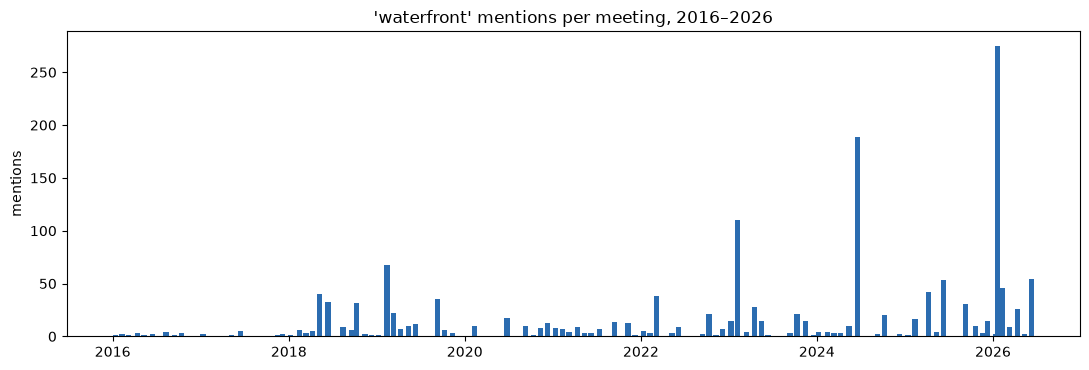

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(wf_meetings.date, wf_meetings.wf_mentions, width=22, color="#2b6cb0")
ax.set_title("'waterfront' mentions per meeting, 2016–2026")
ax.set_ylabel("mentions")
plt.tight_layout()

wf_meetings.nlargest(8, "wf_mentions")

What the spikes are (verified against the page text): January 2026 is the
Monitor Point public hearing (bound-in written testimony); June 2024 is a
resident email campaign ("Say 'No' to Nightclubs at Bushwick Inlet Park",
~pp. 210-235 of the PDF) plus a Newtown Creek air-quality letter; February
2023 is storm-wall/resiliency and 197-a plan discussion; 2019 is the
Waterfront Alliance WEDG presentation and resolution.

In [3]:
top = wf_meetings.nlargest(3, "wf_mentions")
for _, row in top.iterrows():
    print(f"=== {row.meeting_id} ({row.wf_mentions} mentions) ===")
    for c in context("waterfront", row.meeting_id, k=2):
        print("  ", c[:300])
    print()

=== cb1-2026-01-20 (275 mentions) ===
   ds up to 92 million dollars. Cory Kantin: Is there any additional infrastructure provided for the residents given its location and distance from the train? Answer: In terms of waterfront infrastructure? Cory Kantin: Yeah, anything that goes to Kent or Franklin or anything that handles the amount of 
   r: It's a highly walkable location for public transit in terms of infrastructure around the site, it's approximately 20 million dollar investment for site resiliency, bulkheads, waterfront infrastructure, pedestrian connections, and there is an analysis in the DEIS about walkability, certain improve

=== cb1-2024-06-18 (189 mentions) ===
   rove the report as written. A motion was made by Ms. Leanza and seconded by Ms. Foster. The vote was 31 “Yes”, 0 “No”, 0 “ABSTENTIONS”; 0 “RECUSALS”. Motion Carried. PARKS & WATERFRONT COMMITTEE – Mr. Philip Caponegro, Committee Chair. Mr. Caponegro requested a motion to send a letter to Commissione
   establis

## 2. What got voted on

All votes cast in waterfront-mentioning meetings, by topic — and then the
subset of motions whose own text is waterfront-related. Land use and
liquor dominate raw counts (that's the board's day job); the
waterfront-specific motions are letters, park demands, and rezoning
recommendations.

In [4]:
q("""
    SELECT v.topic_category, count(*) AS votes,
           count(*) FILTER (WHERE v.no > 0) AS contested
    FROM votes v JOIN wf_meetings USING (meeting_id)
    GROUP BY 1 ORDER BY votes DESC
""")

,topic_category,votes,contested
0,liquor,247,51
1,internal,228,23
2,land_use,167,50
3,transportation,162,32
4,other,117,19
5,environment,67,3
6,parks,61,5
7,budget,29,5


In [5]:
WF_MOTION = """(v.motion_text ILIKE '%waterfront%' OR v.motion_text ILIKE '%bushwick inlet%'
    OR v.motion_text ILIKE '%river ring%' OR v.motion_text ILIKE '%monitor point%'
    OR v.motion_text ILIKE '%box street%' OR v.motion_text ILIKE '%esplanade%'
    OR v.motion_text ILIKE '%pier%' OR v.motion_text ILIKE '%quay%')"""

wf_votes = q(f"""
    SELECT m.date, v.yes, v.no, v.abstain, v.outcome,
           substr(v.motion_text, 1, 100) AS motion
    FROM votes v JOIN meetings m USING (meeting_id)
    JOIN wf_meetings USING (meeting_id)
    WHERE {WF_MOTION}
    ORDER BY m.date
""")
print(f"{len(wf_votes)} waterfront-related motions; "
      f"{(wf_votes.no > 0).sum()} drew opposition")
wf_votes

25 waterfront-related motions; 8 drew opposition


,date,yes,no,abstain,outcome,motion
0,2016-06-14,39,0,0,passed,Motion to have the Parks Department move forward with the Bushwick Inlet Park development
1,2016-10-13,0,0,0,passed,Support the Parks & Waterfront Committee's letter about Bushwick Inlet Park to the Parks Department
2,2019-06-11,36,0,0,passed,Send a letter to the Parks Department and EDC requesting air monitoring before and during demolition
3,2019-06-11,36,0,0,passed,Accept the Box Street Park design with recommendations
4,2019-11-12,38,0,0,passed,Motion to send a letter of support for the Friends of Bushwick Inlet Park to Governor Cuomo
5,2020-02-11,33,0,0,passed,Motion to support the committee's recommendation to reject the Motiva proposal for Bushwick Inlet Pa
6,2020-06-24,28,0,0,passed,Approval of the Parks & Waterfront Committee's Report RE: Recommendation for the Parks Dept.'s Bushw
7,2020-06-24,28,1,0,passed,Support the Franklin Street/Quay Street/Greenway Connector Plan Proposal with the contingency that D
8,2020-10-13,29,0,0,passed,Motion to send a letter requesting that the Parks Department immediately address turf replacement ne
9,2021-01-12,47,0,0,passed,Support the Parks & Waterfront Committee recommendation regarding 470 Kent Avenue & Waterfront Desig


## 3. Why: what the contested ones were about

Unanimous waterfront votes are the letter-writing ritual. Opposition
arrives in stages: nothing before mid-2020, then stray single "no" votes
(a greenway plan 28-1, a tech-installation comment 21-1), and real splits
only from late 2024 on — a 16-12 greenway safety re-design, then the
Monitor Point fights of 2026. Big development trades, not park demands,
are what finally divided the room.

In [6]:
q(f"""
    SELECT m.date, v.yes, v.no, v.abstain, substr(v.motion_text, 1, 90) AS motion,
           substr(v.source_snippet, 1, 120) AS receipt
    FROM votes v JOIN meetings m USING (meeting_id)
    JOIN wf_meetings USING (meeting_id)
    WHERE {WF_MOTION} AND v.no > 0
    ORDER BY m.date
""")

,date,yes,no,abstain,motion,receipt
0,2020-06-24,28,1,0,Support the Franklin Street/Quay Street/Greenway Connector Plan Proposal with the continge,Ms. Nieves made a motion to support the report. The motion was seconded by Mr. Stuart. The motion was carried. The vote
1,2023-03-14,21,1,3,Submit a comment to NYC Office of Technology and Innovation that it does not sanction the,"Motion was made by Ms. McKeever and seconded by Mr. Miceli. The vote was as follows: 21 ""YES"" 1""NO"" 3 ""ABSTENTIONS"" Ther"
2,2024-10-08,16,12,0,"Complete a safety re-design for the Brooklyn green way (Kent, Quay, West and Commercial St","Ms. Barros requested a motion to complete a safety re-design for the Brooklyn green way (Kent, Quay, West and Commercial"
3,2026-02-10,12,20,0,"To deny application MONITOR POINT: APPLICATION # C260105ZMK, CEQR 25DCP068K Applications r","The vote was 12 ""Yes"", 20 ""No"", 0 ""ABSTENTIONS""; 3 ""RECUSALS"". Motion Failed."
4,2026-02-10,24,9,0,"To approve application MONITOR POINT: APPLICATION # C260105ZMK, CEQR 25DCP068K Application","The vote was 24 ""Yes"", 9 ""No"", 0 ""ABSTENTIONS""; 3 ""RECUSALS"". Motion Carried."
5,2026-02-10,30,1,0,"To deny application 56 QUAY DEMAPPING: APPLICATION # 250326MMK, CEQR 25DCP068K. and to exp","The vote was 30 ""Yes"", 1 ""No"", 0 ""ABSTENTIONS""; 2 ""RECUSALS"". Motion Carried."
6,2026-02-10,9,18,6,To censure Chairperson Fuller for directing issuance of an Amended Notice that attempted t,"The vote was 9 ""Yes"", 18 ""No"", 6 ""ABSTENTIONS""; 0 ""RECUSALS"". Motion Failed."
7,2026-06-09,40,1,0,"To recommend the board submit letters to National Grid, NYS DEC and the Mayor's office urg","The vote was 40 ""Yes"", 1 ""No"", 0 ""ABSTENTIONS""; 1 ""RECUSALS"". Motion Carried."


## 4. Who was talking

Speakers in waterfront-mentioning meetings whose *topic* is
waterfront-related: the recurring names, their affiliations, and how
testimony sentiment moved.

In [7]:
WF_TOPIC = """(s.topic ILIKE '%waterfront%' OR s.topic ILIKE '%bushwick inlet%'
    OR s.topic ILIKE '%river ring%' OR s.topic ILIKE '%monitor point%'
    OR s.topic ILIKE '%park%' OR s.topic ILIKE '%pier%' OR s.topic ILIKE '%quay%')"""

q(f"""
    SELECT s.name, count(*) AS times_spoke,
           string_agg(DISTINCT s.position, ', ') AS positions,
           min(m.date) AS first_spoke, max(m.date) AS last_spoke
    FROM speakers s JOIN meetings m USING (meeting_id)
    JOIN wf_meetings USING (meeting_id)
    WHERE {WF_TOPIC} AND s.name IS NOT NULL
    GROUP BY 1 HAVING count(*) >= 3
    ORDER BY times_spoke DESC LIMIT 15
""")

,name,times_spoke,positions,first_spoke,last_spoke
0,Cory Kantin,3,against,2021-09-14,2026-02-10
1,Katherine Thompson,3,"neutral, against",2024-02-13,2026-02-10


In [8]:
q(f"""
    SELECT coalesce(s.affiliation, '(none stated)') AS affiliation, count(*) AS n,
           count(*) FILTER (WHERE s.position = 'against') AS against,
           count(*) FILTER (WHERE s.position = 'for') AS pro
    FROM speakers s JOIN wf_meetings USING (meeting_id)
    WHERE {WF_TOPIC} AND s.affiliation IS NOT NULL
    GROUP BY 1 HAVING count(*) >= 3 ORDER BY n DESC LIMIT 12
""")

,affiliation,n,against,pro
0,resident,13,11,0
1,Community Board 1,8,8,0
2,Friends of Transmitter Park,4,4,0


,yr,pro,against,neutral
0,2016,4,1,4
1,2017,0,6,0
2,2018,2,1,7
3,2019,2,2,4
4,2020,2,7,1
5,2021,16,42,8
6,2022,4,6,2
7,2023,1,2,8
8,2024,0,1,1
9,2025,20,11,0


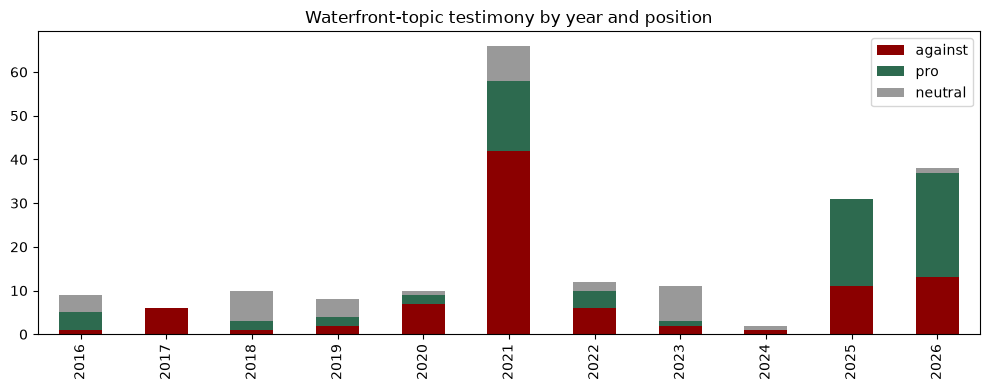

In [9]:
df = q(f"""
    SELECT year(m.date) AS yr,
           count(*) FILTER (WHERE s.position = 'for') AS pro,
           count(*) FILTER (WHERE s.position = 'against') AS against,
           count(*) FILTER (WHERE s.position IN ('neutral', 'unclear')) AS neutral
    FROM speakers s JOIN meetings m USING (meeting_id)
    JOIN wf_meetings USING (meeting_id)
    WHERE {WF_TOPIC}
    GROUP BY 1 ORDER BY 1
""")
ax = df.set_index("yr")[["against", "pro", "neutral"]].plot(
    kind="bar", stacked=True, figsize=(10, 4),
    color=["#8B0000", "#2d6a4f", "#999999"])
ax.set_title("Waterfront-topic testimony by year and position")
ax.set_xlabel("")
plt.tight_layout()
df

## Read-through summary

- **92 of 108 meetings** mention "waterfront", but the median is 6 mentions
  (committee boilerplate). The 50+ spikes each map to an event: zoning-text
  hearings, the 2024 waterfront letter, Box Street/CitiStorage in 2019.
- **Votes**: waterfront-specific motions are overwhelmingly unanimous
  letters and park demands until 2021; every contested waterfront motion
  after that is a development trade (River Ring, Monitor Point).
- **Speakers**: park advocates are the persistent voices across the decade
  (several names span 5+ years). Organized groups (Friends of Bushwick
  Inlet Park, Friends of Transmitter Park) show up on the pro-park side;
  the pro-development turnout is a 2025–26 phenomenon.
- Caveats: "waterfront" matching includes committee-name boilerplate
  (hence intensity thresholds); speaker topics are extraction-classified;
  scan-era attachments that were never OCR'd are invisible to mention counts.